<a href="https://colab.research.google.com/github/kasrasa/ViT-VLM-experiments/blob/VLA-Experiments/VLA_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q -U lerobot
!pip install -q "lerobot[dataset]" av datasets
!pip install --no-binary=av av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 70.9 MB/s eta 0:00:00


In [2]:
import os
import math
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, Subset
import torch.nn.functional as F
from torch import nn
from torchvision.models import resnet50, ResNet50_Weights, convnext_tiny, ConvNeXt_Tiny_Weights
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from lerobot.datasets import LeRobotDataset

In [3]:
DATASET_REPO_ID = "lerobot/pusht" # "lerobot/svla_so101_pickplace"

dataset = LeRobotDataset(DATASET_REPO_ID)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print(torch.cuda.is_available())

print(dataset)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Using device: cuda
True
LeRobotDataset({
    Repository ID: 'lerobot/pusht',
    Number of selected episodes: '206',
    Number of selected samples: '25650',
    Features: '['observation.image', 'observation.state', 'action', 'episode_index', 'frame_index', 'timestamp', 'next.reward', 'next.done', 'next.success', 'index', 'task_index']',
})


In [4]:
sample = dataset[0]

print("Keys in one sample:")
print(sample.keys())

print("\nDetails of dataset[0]:")
for key, value in sample.items():
    print("\n" + "-" * 80)
    print("KEY:", key)
    print("TYPE:", type(value))

    if hasattr(value, "shape"):
        print("SHAPE:", value.shape)
        print("DTYPE:", getattr(value, "dtype", None))
        print("VALUE:")
        print(value)
    else:
        print("VALUE:")
        print(value)

Keys in one sample:
dict_keys(['observation.image', 'observation.state', 'action', 'episode_index', 'frame_index', 'timestamp', 'next.reward', 'next.done', 'next.success', 'index', 'task_index', 'task'])

Details of dataset[0]:

--------------------------------------------------------------------------------
KEY: observation.image
TYPE: <class 'torch.Tensor'>
SHAPE: torch.Size([3, 96, 96])
DTYPE: torch.float32
VALUE:
tensor([[[1.0000, 0.9725, 0.9725,  ..., 0.9725, 0.9725, 1.0000],
         [0.9725, 0.9098, 0.9098,  ..., 0.9098, 0.9098, 0.9725],
         [0.9725, 0.9098, 0.9725,  ..., 1.0000, 0.9098, 0.9725],
         ...,
         [0.9725, 0.9098, 1.0000,  ..., 1.0000, 0.9098, 0.9725],
         [0.9725, 0.9098, 0.9098,  ..., 0.9098, 0.9098, 0.9725],
         [1.0000, 0.9725, 0.9725,  ..., 0.9725, 0.9725, 1.0000]],

        [[1.0000, 0.9725, 0.9725,  ..., 0.9725, 0.9725, 1.0000],
         [0.9725, 0.9098, 0.9098,  ..., 0.9098, 0.9098, 0.9725],
         [0.9725, 0.9098, 0.9725,  ..., 1.0

In [5]:
first_episode_id = int(dataset[0]["episode_index"])
print("First episode ID:", first_episode_id)

episode_indices = []

for i in range(len(dataset)):
    episode_id = int(dataset[i]["episode_index"])

    if episode_id == first_episode_id:
        episode_indices.append(i)
    elif len(episode_indices) > 0:
        break

print("Number of samples/frames in first episode:", len(episode_indices))
print("First dataset index in episode:", episode_indices[0])
print("Last dataset index in episode:", episode_indices[-1])

print("\nFirst frame_index:", dataset[episode_indices[0]]["frame_index"])
print("Last frame_index:", dataset[episode_indices[-1]]["frame_index"])

print("\nFirst timestamp:", dataset[episode_indices[0]]["timestamp"])
print("Last timestamp:", dataset[episode_indices[-1]]["timestamp"])

First episode ID: 0
Number of samples/frames in first episode: 161
First dataset index in episode: 0
Last dataset index in episode: 160

First frame_index: tensor(0)
Last frame_index: tensor(160)

First timestamp: tensor(0.)
Last timestamp: tensor(16.)


In [6]:
def find_keys_containing(sample, keywords):
  keys = []
  for key, value in sample.items():
    key_lower = key.lower()
    if any(word in key_lower for word in keywords):
      keys.append(key)
  return keys

image_keys = find_keys_containing(sample, ["image", "rgb", "camera"])
action_keys = find_keys_containing(sample, ["action"])
state_keys = find_keys_containing(sample, ["state", "joint", "qpos", "robot"])
language_keys = find_keys_containing(sample, ["task", "instruction", "language", "text"])
episode_keys = find_keys_containing(dataset[0], ["episode"])
frame_keys = find_keys_containing(dataset[0], ["frame", "index", "timestamp"])


print("Possible image keys:", image_keys)
print("Possible action keys:", action_keys)
print("Possible state keys:", state_keys)
print("Possible language/task keys:", language_keys)
print("Possible episode keys:", episode_keys)
print("Possible frame/time keys:", frame_keys)

Possible image keys: ['observation.image']
Possible action keys: ['action']
Possible state keys: ['observation.state']
Possible language/task keys: ['task_index', 'task']
Possible episode keys: ['episode_index']
Possible frame/time keys: ['episode_index', 'frame_index', 'timestamp', 'index', 'task_index']


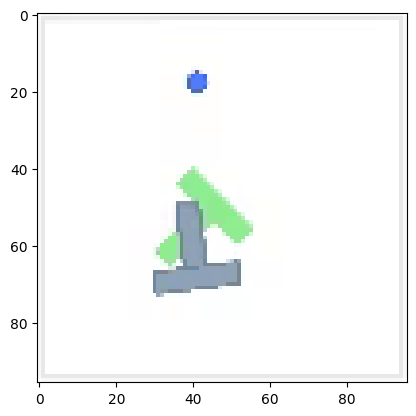

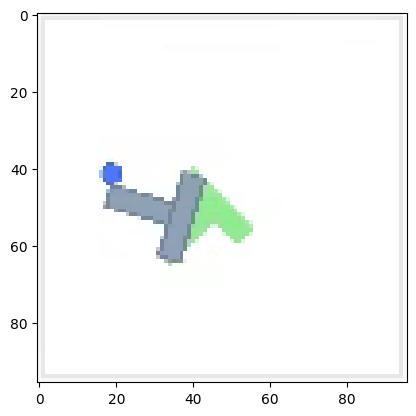

In [7]:
def show_image_tensor(image_tensor):
  img = (image_tensor.detach().cpu().permute(1,2,0).numpy()*255).astype(np.uint8)
  plt.imshow(img)
  plt.show()

show_image_tensor(sample[image_keys[0]])
show_image_tensor(dataset[100][image_keys[0]])
# show_image_tensor(sample[image_keys[1]])
# show_image_tensor(dataset[100][image_keys[1]])

In [8]:
if len(action_keys) > 0:
  action_key = action_keys[0]

  actions = []

  max_samples = min(len(dataset), 5000)
  for idx in tqdm(range(max_samples), desc="Collecting actions"):
    action = dataset[idx][action_key]

    action = action.detach().cpu().numpy() if isinstance(action, torch.Tensor) else action

    action = np.asarray(action).reshape(-1)
    actions.append(action)

  actions = np.stack(actions)

  print("Actions array shape:", actions.shape)

  action_stats_df = pd.DataFrame({
      "dim": np.arange(actions.shape[1]),
      "mean": actions.mean(axis=0),
      "std": actions.std(axis=0),
      "min": actions.min(axis=0),
      "max": actions.max(axis=0),
  })

  display(action_stats_df)

Actions array shape: (5000, 2)


,dim,mean,std,min,max
0,0,225.967804,103.186333,23.0,511.0
1,1,281.851410,99.482811,36.0,498.0


In [9]:
if len(state_keys) > 0:
  state_key = state_keys[0]

  states = []

  max_samples = min(len(dataset), 50000)
  for idx in tqdm(range(max_samples), desc="Collecting actions"):
    state = dataset[idx][state_key]

    state = state.detach().cpu().numpy() if isinstance(state, torch.Tensor) else state

    state = np.asarray(state).reshape(-1)
    states.append(state)

  states = np.stack(states)

  print("States array shape:", states.shape)

  state_stats_df = pd.DataFrame({
      "dim": np.arange(states.shape[1]),
      "mean": states.mean(axis=0),
      "std": states.std(axis=0),
      "min": states.min(axis=0),
      "max": states.max(axis=0),
  })

  display(state_stats_df)

States array shape: (25650, 2)


,dim,mean,std,min,max
0,0,229.111603,101.854828,13.456424,496.146179
1,1,293.311157,96.489395,32.938293,510.957886


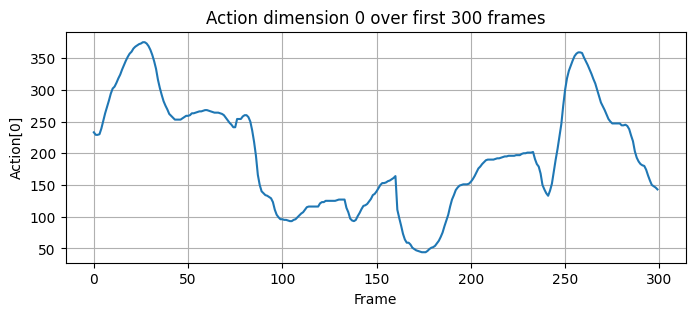

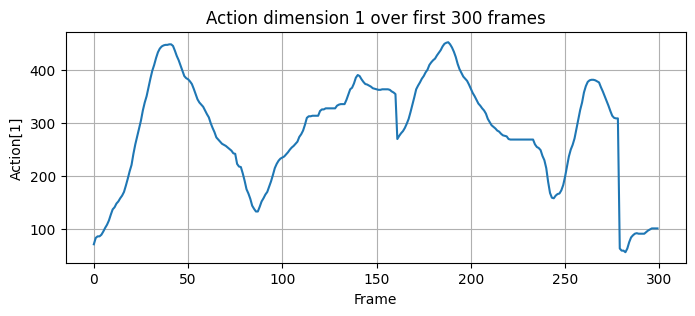

In [10]:
if len(action_keys) > 0:
    num_steps_to_plot = min(300, actions.shape[0])
    num_action_dims = actions.shape[1]

    for dim in range(num_action_dims):
        plt.figure(figsize=(8, 3))
        plt.plot(actions[:num_steps_to_plot, dim])
        plt.title(f"Action dimension {dim} over first {num_steps_to_plot} frames")
        plt.xlabel("Frame")
        plt.ylabel(f"Action[{dim}]")
        plt.grid(True)
        plt.show()

Using episode key: episode_index
Number of episodes inspected: 40


,episode_id,num_frames
0,0,161
1,1,118
2,2,141
3,3,159
4,4,159
5,5,157
6,6,69
7,7,169
8,8,80
9,9,134


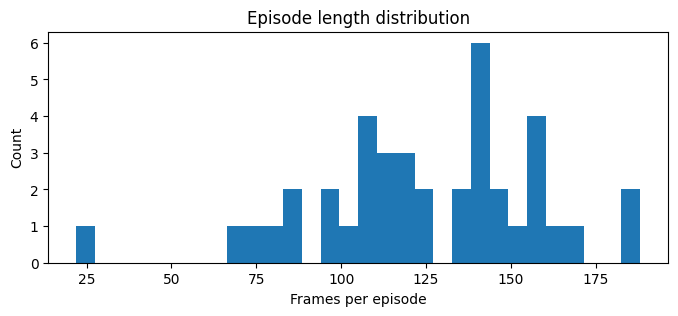

In [11]:
if len(episode_keys) > 0:
    episode_key = episode_keys[0]
    print("Using episode key:", episode_key)

    episode_ids = []

    max_samples = min(len(dataset), 5000)

    for idx in range(max_samples):
        value = dataset[idx][episode_key]

        value = int(value.item()) if isinstance(value, torch.Tensor) else int(value)

        episode_ids.append(value)

    episode_ids = np.asarray(episode_ids)

    unique_ids, count = np.unique(episode_ids, return_counts=True)

    episode_df = pd.DataFrame({
        "episode_id": unique_ids,
        "num_frames": count,
    })

    print("Number of episodes inspected:", len(episode_df))
    display(episode_df.head(20))

    plt.figure(figsize=(8, 3))
    plt.hist(episode_df["num_frames"], bins=30)
    plt.title("Episode length distribution")
    plt.xlabel("Frames per episode")
    plt.ylabel("Count")
    plt.show()
else:
    print("No episode key found.")

In [12]:
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def to_float_tensor(x):
    if isinstance(x, torch.Tensor):
        return x.float()
    return torch.tensor(x, dtype=torch.float32)


def get_scalar_value(x):
    if isinstance(x, torch.Tensor):
        return int(x.item())
    return int(x)

Episode 0 has 161 frames in inspected range.


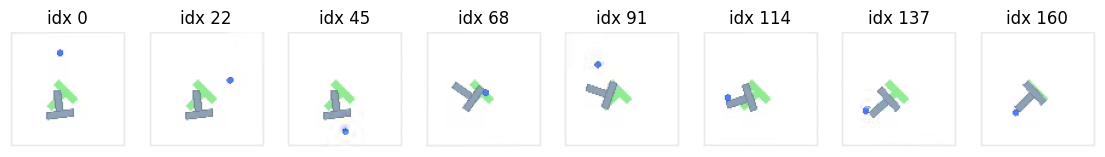

In [13]:
if len(image_keys) > 0 and len(episode_keys) > 0:
    image_key = image_keys[0]
    episode_key = episode_keys[0]

    target_episode = get_scalar_value(dataset[0][episode_key])

    episode_indices = []
    for idx in range(min(len(dataset), 5000)):
        if get_scalar_value(dataset[idx][episode_key]) == target_episode:
            episode_indices.append(idx)

    print(f"Episode {target_episode} has {len(episode_indices)} frames in inspected range.")

    # Pick up to 8 evenly spaced frames from this episode.
    if len(episode_indices) > 0:
        chosen = np.linspace(0, len(episode_indices) - 1, min(8, len(episode_indices))).astype(int)
        chosen_indices = [episode_indices[i] for i in chosen]

        plt.figure(figsize=(14, 4))

        for plot_i, dataset_idx in enumerate(chosen_indices):
            img = dataset[dataset_idx][image_key].detach().cpu()

            if img.ndim == 3 and img.shape[0] in [1, 3, 4]:
                img = img.permute(1, 2, 0)

            img = img.numpy()
            if img.dtype != np.uint8:
                img = np.clip(img, 0, 1)

            plt.subplot(1, len(chosen_indices), plot_i + 1)
            plt.imshow(img)
            plt.title(f"idx {dataset_idx}")
            plt.axis("off")

        plt.show()
else:
    print("Need both image key and episode key to visualize a trajectory.")

In [14]:
if len(language_keys) == 0:
    print("No language/task key found.")
else:
    for key in language_keys:
        print("\nKey:", key)
        values = []

        for idx in range(min(len(dataset), 20)):
            value = dataset[idx][key]
            values.append(value)

        for i, value in enumerate(values[:10]):
            print(f"{i}: {value}")


Key: task_index
0: 0
1: 0
2: 0
3: 0
4: 0
5: 0
6: 0
7: 0
8: 0
9: 0

Key: task
0: Push the T-shaped block onto the T-shaped target.
1: Push the T-shaped block onto the T-shaped target.
2: Push the T-shaped block onto the T-shaped target.
3: Push the T-shaped block onto the T-shaped target.
4: Push the T-shaped block onto the T-shaped target.
5: Push the T-shaped block onto the T-shaped target.
6: Push the T-shaped block onto the T-shaped target.
7: Push the T-shaped block onto the T-shaped target.
8: Push the T-shaped block onto the T-shaped target.
9: Push the T-shaped block onto the T-shaped target.


In [15]:
def split_dataset(dataset, train_split = 0.8, seed = 42):
  num_episodes = dataset.num_episodes
  episode_indices = np.arange(num_episodes)

  np.random.seed(seed)
  np.random.shuffle(episode_indices)

  train_size = int(train_split * num_episodes)
  train_episode_indices = episode_indices[:train_size]
  val_episode_indices = episode_indices[train_size:]

  train_indices = []
  val_indices = []

  for idx in tqdm(range(len(dataset)), desc = "collecting dataset indices"):
    episode_id = dataset[idx]["episode_index"]
    if episode_id in train_episode_indices:
      train_indices.append(idx)
    elif episode_id in val_episode_indices:
      val_indices.append(idx)

  return train_episode_indices, val_episode_indices, train_indices, val_indices

train_episode_indices, val_episode_indices, train_indices, val_indices = split_dataset(dataset)
print("Number of training episodes:", len(train_episode_indices))
print("Number of validation episodes:", len(val_episode_indices))
print("sample train episodes: ", train_episode_indices[:5])
print("sample val episodes: ", val_episode_indices[:5])
print("Number of training samples:", len(train_indices))
print("Number of validation samples:", len(val_indices))
print("sample train indices: ", np.random.randint(0,len(train_indices[:5]),10))
print("sample val indices: ", np.random.randint(0,len(val_indices[:5]),10))

collecting dataset indices:   0%|          | 0/25650 [00:00<?, ?it/s]

Number of training episodes: 164
Number of validation episodes: 42
sample train episodes:  [ 15   9 201  82  68]
sample val episodes:  [ 72 181 134 172 189]
Number of training samples: 20353
Number of validation samples: 5297
sample train indices:  [3 1 3 2 2 0 4 3 1 2]
sample val indices:  [0 0 3 2 4 2 3 3 2 3]


In [16]:
def collect_actions(dataset, indices, action_key):
  actions = []
  for ind in tqdm(indices, desc="Collecting actions"):
    action = to_numpy(dataset[ind][action_key]).reshape(-1).astype(np.float32)
    actions.append(action)

  return np.stack(actions)

train_actions = collect_actions(dataset, train_indices, action_keys[0])
val_actions = collect_actions(dataset, val_indices, action_keys[0])

print("train actions shape: ", train_actions.shape)
print("val actions shape: ", val_actions.shape)

train actions shape:  (20353, 2)
val actions shape:  (5297, 2)


In [17]:
def collect_states(dataset, indices, state_key):
  states = []
  for ind in tqdm(indices, desc="Collecting states"):
    state = to_numpy(dataset[ind][state_key]).reshape(-1).astype(np.float32)
    states.append(state)

  return np.stack(states)

train_states = collect_states(dataset, train_indices, state_keys[0])
val_states = collect_states(dataset, val_indices, state_keys[0])

print("train states shape: ", train_states.shape)
print("val states shape: ", val_states.shape)

train states shape:  (20353, 2)
val states shape:  (5297, 2)


In [18]:
def best_row(history_df, metric="val_mae"):
    return history_df.loc[history_df[metric].idxmin()]


def per_action_dim_metrics(y_true, y_pred):
  y_true = np.asarray(y_true)
  y_pred = np.asarray(y_pred)

  error = y_pred - y_true

  mae = np.mean(np.abs(error), axis=0)
  mse = np.mean(error**2, axis=0)

  true_std = np.std(y_true, axis=0)

  relative_mae = mae / (true_std + 1e-8)

  rows = []
  for dim in range(y_true.shape[1]):
        rows.append({
            "action_dim": dim,
            "mae": mae[dim],
            "relative_mae": relative_mae[dim]
        })

  return pd.DataFrame(rows)


def plot_action_trajectory(y_true, y_pred, num_steps=300):
    n = min(num_steps, len(y_true))

    for dim in range(y_true.shape[1]):
        plt.figure(figsize=(10, 3))

        plt.plot(
            np.arange(n),
            y_true[:n, dim],
            label="Expert action"
        )

        plt.plot(
            np.arange(n),
            y_pred[:n, dim],
            label="Predicted action"
        )

        plt.xlabel("Time step")
        plt.ylabel(f"Action dimension {dim}")
        plt.title(f"Action dimension {dim}")
        plt.legend()
        plt.grid(True)
        plt.show()

# Mean Action Prediciton

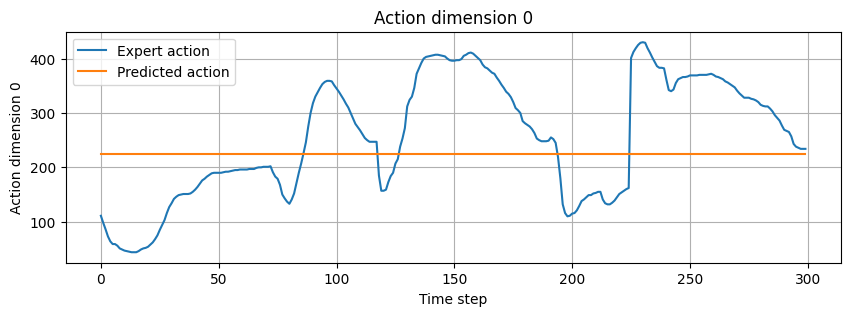

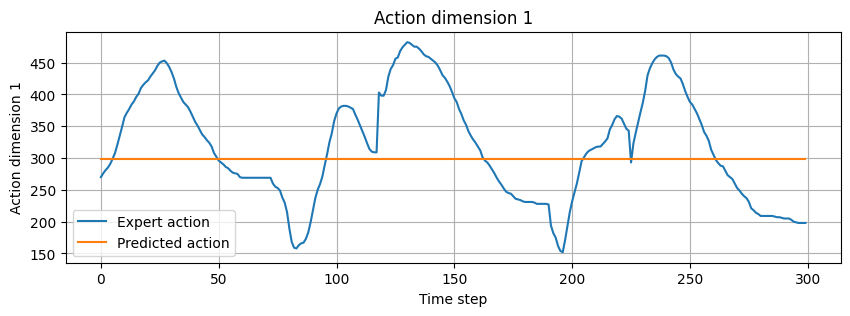

mae:  85.23339
mse:  10281.976


,action_dim,mae,relative_mae
0,0,87.778076,0.855029
1,1,82.687576,0.861610


In [19]:
def mean_action_predictor(dataset, val_indices, action_key, train_actions):
  y_true = collect_actions(dataset, val_indices, action_key)

  train_action_mean = train_actions.mean(axis=0)
  y_pred = np.full_like(y_true, train_action_mean)

  mae = np.mean(np.abs(y_true - y_pred))
  mse = np.mean((y_true - y_pred)**2)

  pre_dim_metrics = per_action_dim_metrics(y_true, y_pred)

  plot_action_trajectory(y_true, y_pred)

  return {
      "mae": mae,
      "mse": mse,
      "per_dim_metrics": pre_dim_metrics
  }


mean_baseline = mean_action_predictor(dataset, val_indices, action_keys[0], train_actions)
print("mae: ", mean_baseline["mae"])
print("mse: ", mean_baseline["mse"])

display(mean_baseline["per_dim_metrics"])

# Previous Action Prediction

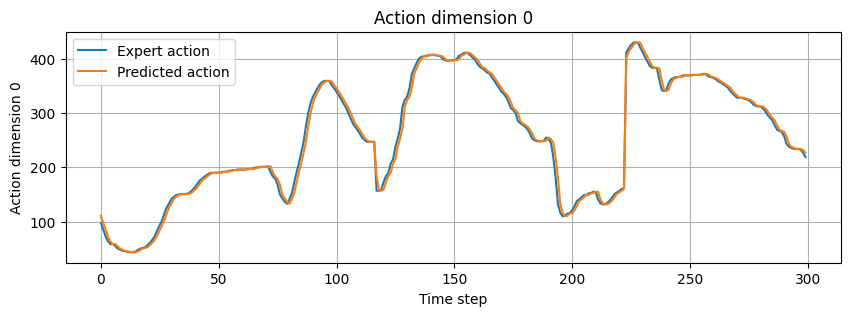

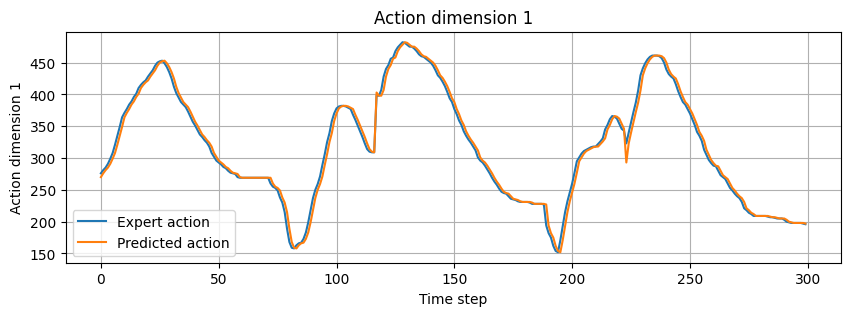

mae:  6.786965
mse:  101.00809


,action_dim,mae,relative_mae
0,0,6.552426,0.063837
1,1,7.021503,0.073378


In [20]:
def _same_episode(idx, episode_key):
  if idx == 0:
    return False

  current_sample = dataset[idx][episode_key]
  previous_sample = dataset[idx-1][episode_key]

  if isinstance(current_sample, torch.Tensor):
      current_sample = int(current_sample.item())
  else:
      current_sample = int(current_sample)

  if isinstance(previous_sample, torch.Tensor):
      previous_sample = int(previous_sample.item())
  else:
      previous_sample = int(previous_sample)

  return current_sample == previous_sample

def previous_action_prediction(dataset, val_indices, action_key, episode_key):
  y_pred = []
  y_true = []

  for ind in tqdm(val_indices, desc="Collecting actions"):
    if ind - 1 not in val_indices:
          continue

    if not _same_episode(ind, episode_key):
      continue

    y_true.append(to_numpy(dataset[ind][action_key]).reshape(-1).astype(np.float32))
    y_pred.append(to_numpy(dataset[ind-1][action_key]).reshape(-1).astype(np.float32))


  y_true = np.stack(y_true)
  y_pred = np.stack(y_pred)

  mae = np.mean(np.abs(y_true - y_pred))
  mse = np.mean((y_true - y_pred)**2)

  per_dim_metrics = per_action_dim_metrics(y_true, y_pred)

  plot_action_trajectory(y_true, y_pred)

  return {
      "mae": mae,
      "mse": mse,
      "per_dim_metrics": per_dim_metrics,
  }


prev_baseline = previous_action_prediction(dataset, val_indices, action_keys[0], episode_keys[0])
print("mae: ", prev_baseline["mae"])
print("mse: ", prev_baseline["mse"])

display(prev_baseline["per_dim_metrics"])

# State Action Predition

In [21]:
class StateActionDataset(Dataset):
  def __init__(self, dataset, indices, state_key, action_key, train_actions, train_states):
    self.dataset = dataset
    self.indices = indices
    self.state_key = state_key
    self.action_key = action_key
    self.train_actions = train_actions
    self.train_states = train_states

    self.train_action_mean = torch.from_numpy(self.train_actions.mean(axis=0)).float()
    self.train_action_std = torch.from_numpy(self.train_actions.std(axis=0) + 1e-6).float()

    self.train_state_mean = torch.from_numpy(self.train_states.mean(axis=0)).float()
    self.train_state_std = torch.from_numpy(self.train_states.std(axis=0) + 1e-6).float()


  def __len__(self):
    return len(self.indices)

  def __getitem__(self, i):
    idx = self.indices[i]
    sample = self.dataset[idx]

    state = to_float_tensor(sample[self.state_key]).reshape(-1)
    action = to_float_tensor(sample[self.action_key]).reshape(-1)

    action_norm = (action - self.train_action_mean) / self.train_action_std
    state_norm = (state - self.train_state_mean) / self.train_state_std

    return {
        "state": state,
        "action": action,
        "action_norm": action_norm,
        "state_norm": state_norm,
        "dataset_index": idx
    }

In [22]:
class MLP_head(torch.nn.Module):
  def __init__(self, state_dim, action_dim, hidden_dim=256):
    super().__init__()
    self.mlp = torch.nn.Sequential(
        torch.nn.Linear(state_dim, hidden_dim),
        torch.nn.ReLU(),
        torch.nn.Linear(hidden_dim, hidden_dim),
        torch.nn.ReLU(),
        torch.nn.Linear(hidden_dim, action_dim)
    )

  def forward(self, state):
    return self.mlp(state)

In [23]:
def train_one_epoch(model, optimizer, train_dataloader, device):
  model.train()
  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(train_dataloader, desc="Training")):
    state_norm, action_norm = batch["state_norm"].to(device), batch["action_norm"].to(device)

    action_pred = model(state_norm)
    loss = F.mse_loss(action_pred, action_norm)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    batch_size = state_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    if step%100 == 0:
      print("running loss at step", step, ":", running_loss / max(total_count, 1))

  return running_loss / max(total_count, 1)


@torch.no_grad()
def evaluate_model(model, val_dataloader, action_mean, action_std, device):
  model.eval()

  action_mean = action_mean.to(device)
  action_std = action_std.to(device)

  all_true = []
  all_pred = []

  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(val_dataloader, desc="Evaluating")):
    state_norm, action_norm = batch["state_norm"].to(device), batch["action_norm"].to(device)
    action = batch["action"].to(device)

    action_pred_norm = model(state_norm)
    loss = F.mse_loss(action_pred_norm, action_norm)

    batch_size = state_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    unnorm_action_pred = action_pred_norm * action_std + action_mean
    all_true.append(action.cpu().numpy())
    all_pred.append(unnorm_action_pred.cpu().numpy())

  all_true = np.concatenate(all_true, axis=0)
  all_pred = np.concatenate(all_pred, axis=0)

  mae = np.mean(np.abs(all_true - all_pred))
  mse = np.mean((all_true - all_pred)**2)

  per_dim_metrics = per_action_dim_metrics(all_true, all_pred)

  return {
        "loss": running_loss / max(total_count, 1),
        "mae": mae,
        "mse": mse,
        "per_dim_metrics": per_dim_metrics,
        "y_true": all_true,
        "y_pred": all_pred,
    }

State dim: 2
Action dim: 2


Training:   0%|          | 0/319 [00:00<?, ?it/s]

running loss at step 0 : 1.4737162590026855
running loss at step 100 : 0.08470488891079284
running loss at step 200 : 0.0635182875305859
running loss at step 300 : 0.056185211231344165


Evaluating:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.0552 | val_loss=0.0492 | val_mae=15.7940 | val_mse=474.4247


...

running loss at step 0 : 0.053590066730976105
running loss at step 100 : 0.044719297752374466
running loss at step 200 : 0.042571857330662696
running loss at step 300 : 0.04112254899997648


Evaluating:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 10 | train_loss=0.0413 | val_loss=0.0471 | val_mae=15.1907 | val_mse=452.7325


Evaluating:   0%|          | 0/83 [00:00<?, ?it/s]

,action_dim,mae,relative_mae
0,0,14.811855,0.144279
1,1,15.569619,0.162236


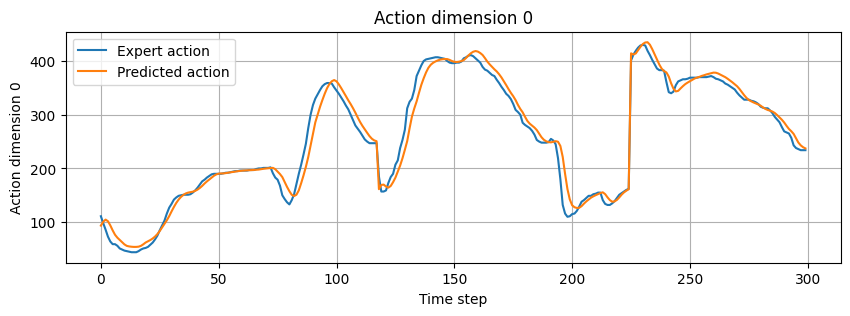

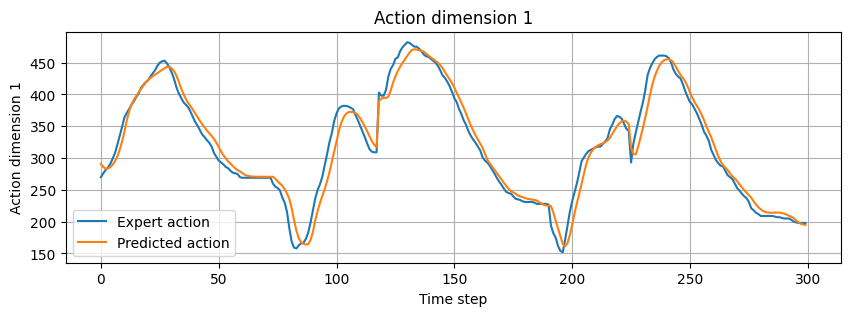

,epoch,train_loss,val_loss,val_mae,val_mse
0,1,0.055205,0.049246,15.793993,474.424713
1,2,0.041177,0.057434,17.310467,548.719666
2,3,0.041771,0.050880,15.875610,490.944366
3,4,0.040765,0.047136,15.370282,453.278503
4,5,0.040637,0.048179,15.515881,463.585602
5,6,0.040801,0.045953,14.998012,441.843109
6,7,0.040251,0.053706,16.365316,515.880798
7,8,0.040894,0.046991,14.990935,451.973083
8,9,0.040329,0.055409,17.518330,533.953491
9,10,0.041312,0.047053,15.190728,452.732483


In [24]:
train_state_ds = StateActionDataset(
    dataset,
    train_indices,
    state_key,
    action_key,
    train_actions,
    train_states,
)

val_state_ds = StateActionDataset(
    dataset,
    val_indices,
    state_key,
    action_key,
    train_actions,
    train_states,
)

sample_batch = train_state_ds[0]
state_dim = sample_batch["state"].numel()
action_dim = sample_batch["action"].numel()

print("State dim:", state_dim)
print("Action dim:", action_dim)

state_train_dataloader = DataLoader(
    train_state_ds,
    batch_size=64,
    shuffle=True,
)

state_val_dataloader = DataLoader(
    val_state_ds,
    batch_size=64,
    shuffle=False,
)

state_model = MLP_head(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=256,
).to(device)

optimizer = torch.optim.AdamW(
    state_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

history = []

NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(
        state_model,
        optimizer,
        state_train_dataloader,
        device,
    )

    val_metrics = evaluate_model(
        state_model,
        state_val_dataloader,
        train_state_ds.train_action_mean,
        train_state_ds.train_action_std,
        device,
    )

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_mae": val_metrics["mae"],
        "val_mse": val_metrics["mse"],
    }

    history.append(row)

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_mae={val_metrics['mae']:.4f} | "
        f"val_mse={val_metrics['mse']:.4f}"
    )

per_dim_val_metrics = evaluate_model(
    state_model,
    state_val_dataloader,
    train_state_ds.train_action_mean,
    train_state_ds.train_action_std,
    device
)

display(per_dim_val_metrics["per_dim_metrics"])
plot_action_trajectory(per_dim_val_metrics["y_true"], per_dim_val_metrics["y_pred"])

state_history_df = pd.DataFrame(history)
display(state_history_df)

# State + Previous Action Prediction

In [25]:
class StatePrevActionDataset(Dataset):
  def __init__(self, dataset, indices, state_key, action_key, episode_key, train_actions, train_states):
    self.dataset = dataset
    self.indices = indices
    self.state_key = state_key
    self.action_key = action_key
    self.episode_key = episode_key
    self.train_actions = train_actions
    self.train_states = train_states

    self.train_action_mean = torch.from_numpy(self.train_actions.mean(axis=0)).float()
    self.train_action_std = torch.from_numpy(self.train_actions.std(axis=0) + 1e-6).float()

    self.train_state_mean = torch.from_numpy(self.train_states.mean(axis=0)).float()
    self.train_state_std = torch.from_numpy(self.train_states.std(axis=0) + 1e-6).float()


  def __len__(self):
    return len(self.indices)

  def _same_episode(self, idx):
    if idx == 0:
      return False

    current_sample = self.dataset[idx][self.episode_key]
    previous_sample = self.dataset[idx-1][self.episode_key]

    if isinstance(current_sample, torch.Tensor):
        current_sample = int(current_sample.item())
    else:
        current_sample = int(current_sample)

    if isinstance(previous_sample, torch.Tensor):
        previous_sample = int(previous_sample.item())
    else:
        previous_sample = int(previous_sample)

    return current_sample == previous_sample

  def __getitem__(self, i):
    idx = self.indices[i]
    sample = self.dataset[idx]

    state = to_float_tensor(sample[self.state_key]).reshape(-1)
    action = to_float_tensor(sample[self.action_key]).reshape(-1)

    action_norm = (action - self.train_action_mean) / self.train_action_std
    state_norm = (state - self.train_state_mean) / self.train_state_std

    if self._same_episode(idx):
      previous_action = to_float_tensor(self.dataset[idx-1][self.action_key]).reshape(-1)
      previous_action_norm = (previous_action - self.train_action_mean) / self.train_action_std
      has_previous_action = torch.tensor([1.0])
    else:
      previous_action = torch.zeros_like(action)
      previous_action_norm = torch.zeros_like(action_norm)
      has_previous_action = torch.tensor([0.0])

    input_bundle = torch.cat([state, previous_action, has_previous_action], dim=0)
    input_norm_bundle = torch.cat([state_norm, previous_action_norm, has_previous_action], dim=0)

    return {
        "state": input_bundle,
        "action": action,
        "action_norm": action_norm,
        "state_norm": input_norm_bundle,
        "dataset_index": idx
    }

State dim: 5
Action dim: 2


Training:   0%|          | 0/319 [00:00<?, ?it/s]

running loss at step 0 : 0.8720234036445618
running loss at step 100 : 0.057777110791516186
running loss at step 200 : 0.03584154098947991
running loss at step 300 : 0.026478845774632356


Evaluating:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.0254 | val_loss=0.0097 | val_mae=6.8211 | val_mse=91.9739


...

running loss at step 0 : 0.003952364437282085
running loss at step 100 : 0.004779553312882043
running loss at step 200 : 0.004617910027105491
running loss at step 300 : 0.004808791811373766


Evaluating:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 10 | train_loss=0.0048 | val_loss=0.0048 | val_mae=4.0666 | val_mse=46.2302


Evaluating:   0%|          | 0/83 [00:00<?, ?it/s]

,action_dim,mae,relative_mae
0,0,4.193339,0.040847
1,1,3.939893,0.041054


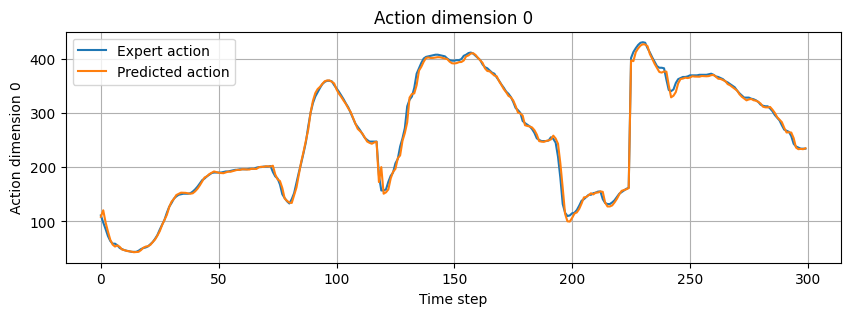

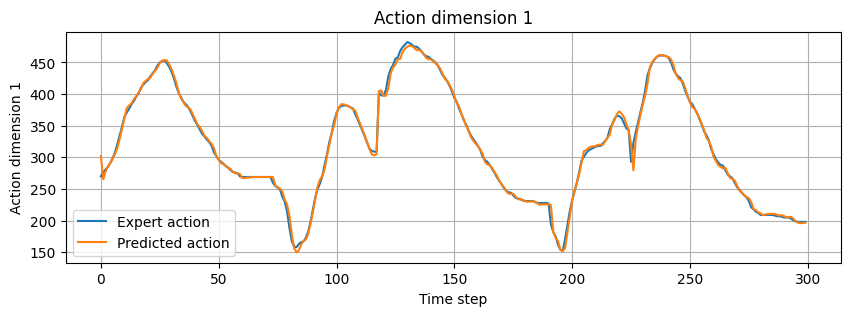

,epoch,train_loss,val_loss,val_mae,val_mse
0,1,0.025406,0.009699,6.821075,91.973946
1,2,0.005560,0.005629,4.748552,54.063496
2,3,0.005132,0.006853,5.710990,66.916191
3,4,0.005225,0.006121,5.095111,58.950893
4,5,0.005133,0.005383,4.596549,51.811131
5,6,0.005150,0.008018,6.212503,76.540756
6,7,0.005064,0.011396,7.397783,113.316864
7,8,0.005215,0.008292,6.381896,78.388977
8,9,0.004870,0.005135,4.478753,49.598530
9,10,0.004828,0.004788,4.066614,46.230206


In [26]:
train_prevaction_ds = StatePrevActionDataset(
    dataset,
    train_indices,
    state_key,
    action_key,
    episode_key,
    train_actions,
    train_states,
)

val_prevaction_ds = StatePrevActionDataset(
    dataset,
    val_indices,
    state_key,
    action_key,
    episode_key,
    train_actions,
    train_states,
)

sample_batch = train_prevaction_ds[0]
state_dim = sample_batch["state_norm"].numel()
action_dim = sample_batch["action"].numel()

print("State dim:", state_dim)
print("Action dim:", action_dim)

prevaction_train_dataloader = DataLoader(
    train_prevaction_ds,
    batch_size=64,
    shuffle=True,
)

prevaction_val_dataloader = DataLoader(
    val_prevaction_ds,
    batch_size=64,
    shuffle=False,
)

prevaction_model = MLP_head(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=256,
).to(device)

optimizer = torch.optim.AdamW(
    prevaction_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

history = []

NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(
        prevaction_model,
        optimizer,
        prevaction_train_dataloader,
        device,
    )

    val_metrics = evaluate_model(
        prevaction_model,
        prevaction_val_dataloader,
        train_prevaction_ds.train_action_mean,
        train_prevaction_ds.train_action_std,
        device,
    )

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_mae": val_metrics["mae"],
        "val_mse": val_metrics["mse"],
    }

    history.append(row)

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_mae={val_metrics['mae']:.4f} | "
        f"val_mse={val_metrics['mse']:.4f}"
    )

final_per_dim_val_metrics = evaluate_model(
    prevaction_model,
    prevaction_val_dataloader,
    train_prevaction_ds.train_action_mean,
    train_prevaction_ds.train_action_std,
    device
)

display(final_per_dim_val_metrics["per_dim_metrics"])
plot_action_trajectory(final_per_dim_val_metrics["y_true"], final_per_dim_val_metrics["y_pred"])

prevaction_history_df = pd.DataFrame(history)
display(prevaction_history_df)

# State + k Previous Action Prediction

In [27]:
class StatePrevKActionDataset(Dataset):
  def __init__(self, dataset, indices, state_key, action_key, episode_key, train_actions, train_states, k=2):
    self.dataset = dataset
    self.state_key = state_key
    self.action_key = action_key
    self.episode_key = episode_key
    self.train_actions = train_actions
    self.train_states = train_states
    self.k = k
    self.indices = [int(idx) for idx in list(indices) if self._same_episode(int(idx))]

    self.train_action_mean = torch.from_numpy(self.train_actions.mean(axis=0)).float()
    self.train_action_std = torch.from_numpy(self.train_actions.std(axis=0) + 1e-6).float()

    self.train_state_mean = torch.from_numpy(self.train_states.mean(axis=0)).float()
    self.train_state_std = torch.from_numpy(self.train_states.std(axis=0) + 1e-6).float()


  def __len__(self):
    return len(self.indices)

  def _same_episode(self, idx):
    if idx-self.k < 0:
      return False

    current_sample = self.dataset[idx][self.episode_key]
    previous_sample_k = self.dataset[idx-self.k][self.episode_key]

    if isinstance(current_sample, torch.Tensor):
        current_sample = int(current_sample.item())
    else:
        current_sample = int(current_sample)

    if isinstance(previous_sample_k, torch.Tensor):
      previous_sample_k = int(previous_sample_k.item())
    else:
      previous_sample_k = int(previous_sample_k)

    return current_sample == previous_sample_k

  def __getitem__(self, i):
    previous_actions_k = []
    previous_actions_k_norm = []
    previous_states_k = []
    previous_states_k_norm = []

    idx = self.indices[i]
    sample = self.dataset[idx]

    state = to_float_tensor(sample[self.state_key]).reshape(-1)
    action = to_float_tensor(sample[self.action_key]).reshape(-1)

    action_norm = (action - self.train_action_mean) / self.train_action_std
    state_norm = (state - self.train_state_mean) / self.train_state_std

    for offset in range(1, self.k+1):
      previous_action_k = to_float_tensor(self.dataset[idx-offset][self.action_key]).reshape(-1)
      previous_action_k_norm = (previous_action_k - self.train_action_mean) / self.train_action_std

      previous_state_k = to_float_tensor(self.dataset[idx-offset][self.state_key]).reshape(-1)
      previous_state_k_norm = (previous_state_k - self.train_state_mean) / self.train_state_std

      previous_actions_k.append(previous_action_k)
      previous_actions_k_norm.append(previous_action_k_norm)

      previous_states_k.append(previous_state_k)
      previous_states_k_norm.append(previous_state_k_norm)

    previous_actions_k = torch.cat(previous_actions_k, dim=0)
    previous_actions_k_norm = torch.cat(previous_actions_k_norm, dim=0)

    previous_states_k = torch.cat(previous_states_k, dim=0)
    previous_states_k_norm = torch.cat(previous_states_k_norm, dim=0)

    input_bundle = torch.cat([state, previous_states_k, previous_actions_k], dim=0)
    input_norm_bundle = torch.cat([state_norm, previous_states_k_norm, previous_actions_k_norm], dim=0)

    return {
        "state": input_bundle,
        "action": action,
        "action_norm": action_norm,
        "state_norm": input_norm_bundle,
        "dataset_index": idx
    }

State dim: 10
Action dim: 2


Training:   0%|          | 0/313 [00:00<?, ?it/s]

running loss at step 0 : 0.9450633525848389
running loss at step 100 : 0.056344297025260504
running loss at step 200 : 0.031629383656664276
running loss at step 300 : 0.022970292444938045


Evaluating:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.0223 | val_loss=0.0055 | val_mae=4.5505 | val_mse=53.1460


...

running loss at step 0 : 0.005259288940578699
running loss at step 100 : 0.0034873019788635544
running loss at step 200 : 0.0032842977844706888
running loss at step 300 : 0.0033698642036206154


Evaluating:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 10 | train_loss=0.0034 | val_loss=0.0039 | val_mae=3.9896 | val_mse=37.4106


Evaluating:   0%|          | 0/82 [00:00<?, ?it/s]

,action_dim,mae,relative_mae
0,0,3.696082,0.036024
1,1,4.283061,0.044907


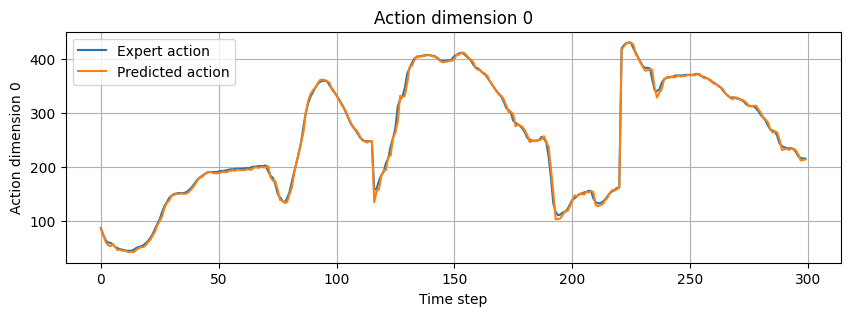

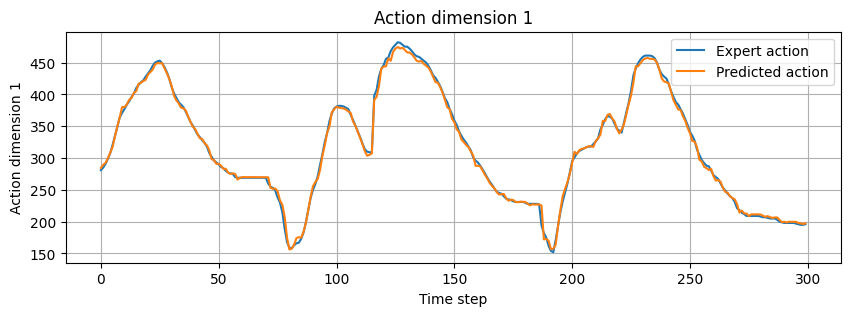

,epoch,train_loss,val_loss,val_mae,val_mse
0,1,0.022297,0.005534,4.550528,53.145981
1,2,0.004403,0.003853,3.749296,37.154110
2,3,0.003833,0.003538,3.586182,34.140682
3,4,0.003654,0.004809,4.641098,45.787849
4,5,0.003716,0.004422,4.530653,42.938866
5,6,0.003534,0.004140,4.227515,40.144058
6,7,0.003535,0.003516,3.712582,33.969746
7,8,0.003484,0.003931,3.997797,37.898899
8,9,0.003364,0.003961,4.083312,38.602058
9,10,0.003357,0.003890,3.989570,37.410610


State dim: 18
Action dim: 2


Training:   0%|          | 0/308 [00:00<?, ?it/s]

running loss at step 0 : 0.9456140995025635
running loss at step 100 : 0.06211092736166302
running loss at step 200 : 0.03619630526593743
running loss at step 300 : 0.026556916732149216


Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 09 | train_loss=0.0036 | val_loss=0.0038 | val_mae=3.9530 | val_mse=37.1101


Training:   0%|          | 0/308 [00:00<?, ?it/s]

running loss at step 0 : 0.005034441594034433
running loss at step 100 : 0.0032710988019214998
running loss at step 200 : 0.0034518210473354553
running loss at step 300 : 0.0035066025179232227


Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
K = [2,4,8]
prevk_histories_df = {}

for k in K:
  train_prevk_ds = StatePrevKActionDataset(
      dataset,
      train_indices,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k = k
  )

  val_prevk_ds = StatePrevKActionDataset(
      dataset,
      val_indices,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k = k
  )

  sample_batch = train_prevk_ds[0]
  state_dim = sample_batch["state_norm"].numel()
  action_dim = sample_batch["action"].numel()

  print("State dim:", state_dim)
  print("Action dim:", action_dim)

  prevk_train_dataloader = DataLoader(
      train_prevk_ds,
      batch_size=64,
      shuffle=True,
  )

  prevk_val_dataloader = DataLoader(
      val_prevk_ds,
      batch_size=64,
      shuffle=False,
  )

  prevk_model = MLP_head(
      state_dim=state_dim,
      action_dim=action_dim,
      hidden_dim=256,
  ).to(device)

  optimizer = torch.optim.AdamW(
      prevk_model.parameters(),
      lr=1e-3,
      weight_decay=1e-4,
  )

  history = []

  NUM_EPOCHS = 10

  for epoch in range(NUM_EPOCHS):
      train_loss = train_one_epoch(
          prevk_model,
          optimizer,
          prevk_train_dataloader,
          device,
      )

      val_metrics = evaluate_model(
          prevk_model,
          prevk_val_dataloader,
          train_prevk_ds.train_action_mean,
          train_prevk_ds.train_action_std,
          device,
      )

      row = {
          "epoch": epoch + 1,
          "train_loss": train_loss,
          "val_loss": val_metrics["loss"],
          "val_mae": val_metrics["mae"],
          "val_mse": val_metrics["mse"],
      }

      history.append(row)

      print(
          f"Epoch {epoch+1:02d} | "
          f"train_loss={train_loss:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | "
          f"val_mae={val_metrics['mae']:.4f} | "
          f"val_mse={val_metrics['mse']:.4f}"
      )

  final_per_dim_val_metrics = evaluate_model(
      prevk_model,
      prevk_val_dataloader,
      train_prevk_ds.train_action_mean,
      train_prevk_ds.train_action_std,
      device
  )

  display(final_per_dim_val_metrics["per_dim_metrics"])
  plot_action_trajectory(final_per_dim_val_metrics["y_true"], final_per_dim_val_metrics["y_pred"])

  prevk_histories_df[k] = pd.DataFrame(history)
  display(prevk_histories_df[k])

# GRU Policy

In [ ]:
class GRUDataset(Dataset):
  def __init__(self, dataset, indices, state_key, action_key, episode_key, train_actions, train_states, k=2):
    self.dataset = dataset
    self.state_key = state_key
    self.action_key = action_key
    self.episode_key = episode_key
    self.train_actions = train_actions
    self.train_states = train_states
    self.k = k
    self.indices = [int(idx) for idx in list(indices) if self._same_episode(int(idx))]

    self.train_action_mean = torch.from_numpy(self.train_actions.mean(axis=0)).float()
    self.train_action_std = torch.from_numpy(self.train_actions.std(axis=0) + 1e-6).float()

    self.train_state_mean = torch.from_numpy(self.train_states.mean(axis=0)).float()
    self.train_state_std = torch.from_numpy(self.train_states.std(axis=0) + 1e-6).float()


  def __len__(self):
    return len(self.indices)

  def _same_episode(self, idx):
    if idx-self.k < 0:
      return False

    current_sample = self.dataset[idx][self.episode_key]
    previous_sample_k = self.dataset[idx-self.k][self.episode_key]

    if isinstance(current_sample, torch.Tensor):
        current_sample = int(current_sample.item())
    else:
        current_sample = int(current_sample)

    if isinstance(previous_sample_k, torch.Tensor):
      previous_sample_k = int(previous_sample_k.item())
    else:
      previous_sample_k = int(previous_sample_k)

    return current_sample == previous_sample_k

  def __getitem__(self, i):
    idx = self.indices[i]
    sample = self.dataset[idx]

    state = to_float_tensor(sample[self.state_key]).reshape(-1)
    action = to_float_tensor(sample[self.action_key]).reshape(-1)

    action_norm = (action - self.train_action_mean) / self.train_action_std
    state_norm = (state - self.train_state_mean) / self.train_state_std

    # Current state/action pairs
    # [state_(t), zeros, action not available]
    current_token = torch.cat([state_norm, torch.zeros_like(action_norm), torch.tensor([0.0])], dim=0)

    sequence = []


    # -----------------------------------------
    # Historical state/action pairs
    #
    # [state_(t-k), action_(t-k), action available]
    # ...
    # [state_(t-1), action_(t-1), action available]
    # -----------------------------------------
    for offset in range(self.k, 0, -1):
      previous_action_k = to_float_tensor(self.dataset[idx-offset][self.action_key]).reshape(-1)
      previous_action_k_norm = (previous_action_k - self.train_action_mean) / self.train_action_std

      previous_state_k = to_float_tensor(self.dataset[idx-offset][self.state_key]).reshape(-1)
      previous_state_k_norm = (previous_state_k - self.train_state_mean) / self.train_state_std

      token = torch.cat([previous_state_k_norm, previous_action_k_norm, torch.tensor([1.0])], dim=0)
      sequence.append(token)

    sequence.append(current_token)
    sequence = torch.stack(sequence, dim=0)

    return {
        "action": action,
        "action_norm": action_norm,
        "state_norm": sequence,
        "dataset_index": idx
    }

In [ ]:
class GRUActionPolicy(nn.Module):
    def __init__(
        self,
        input_dim,
        action_dim,
        hidden_dim=256,
        num_layers=2,
        dropout=0.1,
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.action_head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, sequence_norm):
        output, hidden = self.gru(sequence_norm)
        last_hidden = output[:, -1, :]
        action_norm = self.action_head(last_hidden)
        return action_norm

In [ ]:
K = [2,4,8]
gru_histories_df = {}

for k in K:
  train_gru_ds = GRUDataset(
      dataset,
      train_indices,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k = k
  )

  val_gru_ds = GRUDataset(
      dataset,
      val_indices,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k = k
  )

  sample_batch = train_gru_ds[0]
  state_dim = sample_batch["state_norm"].shape[1]
  action_dim = sample_batch["action_norm"].numel()

  print("State dim:", state_dim)
  print("Action dim:", action_dim)

  gru_train_dataloader = DataLoader(
      train_gru_ds,
      batch_size=64,
      shuffle=True,
  )

  gru_val_dataloader = DataLoader(
      val_gru_ds,
      batch_size=64,
      shuffle=False,
  )

  gru_model = GRUActionPolicy(
    input_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=256,
    num_layers=3,
    dropout=0.2,
  ).to(device)

  optimizer = torch.optim.AdamW(
      gru_model.parameters(),
      lr=1e-3,
      weight_decay=1e-4,
  )

  sample_batch = next(iter(gru_train_dataloader))
  x = sample_batch["state_norm"].to(device)

  with torch.no_grad():
      pred = gru_model(x)

  print("input:", x.shape)
  print("prediction:", pred.shape)

  history = []

  NUM_EPOCHS = 10

  for epoch in range(NUM_EPOCHS):
      train_loss = train_one_epoch(
          gru_model,
          optimizer,
          gru_train_dataloader,
          device,
      )

      val_metrics = evaluate_model(
          gru_model,
          gru_val_dataloader,
          train_gru_ds.train_action_mean,
          train_gru_ds.train_action_std,
          device,
      )

      row = {
          "epoch": epoch + 1,
          "train_loss": train_loss,
          "val_loss": val_metrics["loss"],
          "val_mae": val_metrics["mae"],
          "val_mse": val_metrics["mse"],
      }

      history.append(row)

      print(
          f"Epoch {epoch+1:02d} | "
          f"train_loss={train_loss:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | "
          f"val_mae={val_metrics['mae']:.4f} | "
          f"val_mse={val_metrics['mse']:.4f}"
      )

  final_per_dim_val_metrics = evaluate_model(
    gru_model,
    gru_val_dataloader,
    train_gru_ds.train_action_mean,
    train_gru_ds.train_action_std,
    device
    )

  display(final_per_dim_val_metrics["per_dim_metrics"])
  plot_action_trajectory(final_per_dim_val_metrics["y_true"], final_per_dim_val_metrics["y_pred"])

  gru_histories_df[k] = pd.DataFrame(history)
  display(gru_histories_df[k])

# Image Action Prediction

In [ ]:
class ImageActionDataset(Dataset):
  def __init__(self, dataset, indices, image_key, action_key, train_actions):
    self.dataset = dataset
    self.indices = indices
    self.image_key = image_key
    self.action_key = action_key
    self.train_actions = train_actions

    self.train_action_mean = torch.from_numpy(self.train_actions.mean(axis=0)).float()
    self.train_action_std = torch.from_numpy(self.train_actions.std(axis=0) + 1e-6).float()

  def __len__(self):
    return len(self.indices)

  def __getitem__(self, i):
    idx = self.indices[i]
    sample = self.dataset[idx]

    action = to_float_tensor(sample[self.action_key]).reshape(-1)
    image = to_float_tensor(sample[self.image_key])

    action_norm = (action - self.train_action_mean) / self.train_action_std
    image_norm = image/255.0 if image.max() > 2.0 else image

    return {
        "image": image,
        "action": action,
        "image_norm": image_norm,
        "action_norm": action_norm,
        "dataset_index": idx
    }

In [ ]:
class CNNModel(nn.Module):
  def __init__(self, action_dim):
    super().__init__()

    self.backbone = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),

        nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),

        nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),

        nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU()
    )

    self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 256 * 2 * 2),
            nn.ReLU(),
            nn.Linear(256 * 2 * 2, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim),
        )

  def forward(self, image):
    encoded = self.backbone(image)
    return self.head(encoded)

In [ ]:
def train_one_epoch_image(model, optimizer, train_dataloader, device):
  model.train()
  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(train_dataloader, desc="Training")):
    image_norm = batch["image_norm"].to(device)
    action_norm = batch["action_norm"].to(device)

    action_pred = model(image_norm)
    loss = F.mse_loss(action_pred, action_norm)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    batch_size = action_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    if step%100 == 0:
      print("running loss at step", step, ":", running_loss / max(total_count, 1))

  return running_loss / max(total_count, 1)

@torch.no_grad()
def evaluate_model_image(model, val_dataloader, action_mean, action_std, device):
  model.eval()

  action_mean = action_mean.to(device)
  action_std = action_std.to(device)

  all_true = []
  all_pred = []

  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(val_dataloader, desc="Evaluating")):
    image_norm = batch["image_norm"].to(device)
    action_norm = batch["action_norm"].to(device)
    action = batch["action"].to(device)

    action_pred_norm = model(image_norm)
    loss = F.mse_loss(action_pred_norm, action_norm)

    batch_size = action_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    unnorm_action_pred = action_pred_norm * action_std + action_mean
    all_true.append(action.cpu().numpy())
    all_pred.append(unnorm_action_pred.cpu().numpy())

  all_true = np.concatenate(all_true, axis=0)
  all_pred = np.concatenate(all_pred, axis=0)

  mae = np.mean(np.abs(all_true - all_pred))
  mse = np.mean((all_true - all_pred)**2)

  per_dim_metrics = per_action_dim_metrics(all_true, all_pred)

  return {
        "loss": running_loss / max(total_count, 1),
        "mae": mae,
        "mse": mse,
        "per_dim_metrics": per_dim_metrics,
        "y_true": all_true,
        "y_pred": all_pred
  }

In [ ]:
train_image_ds = ImageActionDataset(
        dataset,
        train_indices,
        image_key,
        action_key,
        train_actions
    )

val_image_ds = ImageActionDataset(
    dataset,
    val_indices,
    image_key,
    action_key,
    train_actions
)

sample_batch = train_image_ds[0]
action_dim = sample_batch["action"].numel()

image_train_loader = DataLoader(train_image_ds, batch_size=64, shuffle=True)
image_val_loader = DataLoader(val_image_ds, batch_size=64, shuffle=False)

image_model = CNNModel(action_dim=action_dim).to(device)

optimizer = torch.optim.AdamW(image_model.parameters(), lr=1e-3, weight_decay=1e-4)

image_history = []

NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch_image(
        image_model,
        optimizer,
        image_train_loader,
        device,
    )

    val_metrics = evaluate_model_image(
        image_model,
        image_val_loader,
        train_image_ds.train_action_mean,
        train_image_ds.train_action_std,
        device,
    )

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_mae": val_metrics["mae"],
        "val_mse": val_metrics["mse"],
    }

    image_history.append(row)

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_mae={val_metrics['mae']:.4f}"
        f"val_mse={val_metrics['mse']:.4f}"
    )

final_val_metrics = evaluate_model_image(
    image_model,
    image_val_loader,
    train_image_ds.train_action_mean,
    train_image_ds.train_action_std,
    device
)

display(final_val_metrics["per_dim_metrics"])
plot_action_trajectory(final_val_metrics["y_true"], final_val_metrics["y_pred"])

image_history_df = pd.DataFrame(image_history)
display(image_history_df)

# Image State Previous K Action Prediction

In [ ]:
class ImagekPrevActionDataset(Dataset):
  def __init__(self, dataset, indices, image_key, state_key, action_key, episode_key, train_actions, train_states, k):
    self.dataset = dataset
    self.image_key = image_key
    self.state_key = state_key
    self.action_key = action_key
    self.episode_key = episode_key
    self.train_actions = train_actions
    self.train_states = train_states
    self.k = k
    self.indices = [int(idx) for idx in list(indices) if self._same_episode(int(idx))]

    self.train_action_mean = torch.from_numpy(self.train_actions.mean(axis=0)).float()
    self.train_action_std = torch.from_numpy(self.train_actions.std(axis=0) + 1e-6).float()

    self.train_state_mean = torch.from_numpy(self.train_states.mean(axis=0)).float()
    self.train_state_std = torch.from_numpy(self.train_states.std(axis=0) + 1e-6).float()


  def __len__(self):
    return len(self.indices)

  def _same_episode(self, idx):
    if idx-self.k < 0:
      return False

    current_sample = self.dataset[idx][self.episode_key]
    previous_sample_k = self.dataset[idx-self.k][self.episode_key]

    if isinstance(current_sample, torch.Tensor):
        current_sample = int(current_sample.item())
    else:
        current_sample = int(current_sample)

    if isinstance(previous_sample_k, torch.Tensor):
      previous_sample_k = int(previous_sample_k.item())
    else:
      previous_sample_k = int(previous_sample_k)

    return current_sample == previous_sample_k

  def __getitem__(self, i):
    idx = self.indices[i]
    sample = self.dataset[idx]

    state = to_float_tensor(sample[self.state_key]).reshape(-1)
    action = to_float_tensor(sample[self.action_key]).reshape(-1)

    action_norm = (action - self.train_action_mean) / self.train_action_std
    state_norm = (state - self.train_state_mean) / self.train_state_std

    # Current state/action pairs
    # [state_(t), zeros, action not available]
    current_token = torch.cat([state_norm, torch.zeros_like(action_norm), torch.tensor([0.0])], dim=0)

    sequence = []

    # -----------------------------------------
    # Historical state/action pairs
    #
    # [state_(t-k), action_(t-k), action available]
    # ...
    # [state_(t-1), action_(t-1), action available]
    # -----------------------------------------
    for offset in range(self.k, 0, -1):
      previous_action_k = to_float_tensor(self.dataset[idx-offset][self.action_key]).reshape(-1)
      previous_action_k_norm = (previous_action_k - self.train_action_mean) / self.train_action_std

      previous_state_k = to_float_tensor(self.dataset[idx-offset][self.state_key]).reshape(-1)
      previous_state_k_norm = (previous_state_k - self.train_state_mean) / self.train_state_std

      token = torch.cat([previous_state_k_norm, previous_action_k_norm, torch.tensor([1.0])], dim=0)
      sequence.append(token)

    sequence.append(current_token)
    sequence = torch.stack(sequence, dim=0)

    image = to_float_tensor(sample[self.image_key])
    image_norm = image/255.0 if image.max() > 2.0 else image

    return {
        "image": image,
        "action": action,
        "image_norm": image_norm,
        "state_norm": sequence,
        "action_norm": action_norm,
        "dataset_index": idx
    }

In [ ]:
class kActionImageEncoder(nn.Module):
  def __init__(self, backbone_name = "convnext_tiny", embedding_dim=256, freeze_backbone=True):
    super().__init__()

    self.backbone_name = backbone_name
    self.freeze_backbone = freeze_backbone

    if backbone_name == "resnet50":
        weights = ResNet50_Weights.IMAGENET1K_V2
        model = resnet50(weights=weights)

        feature_dim = model.fc.in_features
        model.fc = nn.Identity()

        self.backbone = model

    elif backbone_name == "convnext_tiny":
        weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        model = convnext_tiny(weights=weights)

        feature_dim = model.classifier[-1].in_features

        self.backbone = nn.Sequential(
            model.features,
            model.avgpool,
            nn.Flatten(1),
        )

    else:
        raise ValueError(
            f"Unknown backbone: {backbone_name}. "
            "Use 'resnet50' or 'convnext_tiny'."
        )

    if self.freeze_backbone:
      for param in self.backbone.parameters():
          param.requires_grad = False

    self.head = nn.Sequential(
        nn.Linear(feature_dim, 512),
        nn.ReLU(),
        nn.Linear(512, embedding_dim),
        )

  def forward(self, image):
    if self.freeze_backbone:
        self.backbone.eval()

        with torch.no_grad():
            encoded = self.backbone(image)
    else:
        encoded = self.backbone(image)
    return self.head(encoded)

In [ ]:
class GRUEncoder(nn.Module):
    def __init__(
        self,
        input_dim,
        embedding_dim=256,
        hidden_dim=256,
        num_layers=2,
        dropout=0.1,
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.projection = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, embedding_dim),
            nn.ReLU(),
        )

    def forward(self, sequence_norm):
        _, hidden = self.gru(sequence_norm)
        last_hidden = hidden[-1]
        embedding = self.projection(last_hidden)
        return embedding

In [ ]:
class FusionMLP(nn.Module):
  def __init__(self, input_dim, action_dim, hidden_dim=512):
    super().__init__()
    self.input_dim = input_dim
    self.action_dim = action_dim
    self.hidden_dim = hidden_dim

    self.mlp = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, action_dim),
    )

  def forward(self, input_bundle):
    return self.mlp(input_bundle)

In [ ]:
def train_one_epoch_image_kprev(image_model, gru_model, fusion_head, optimizer, train_dataloader, device):
  image_model.train()
  gru_model.train()
  fusion_head.train()
  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(train_dataloader, desc="Training")):
    image_norm = batch["image_norm"].to(device)
    state_norm = batch["state_norm"].to(device)
    action_norm = batch["action_norm"].to(device)

    image_embedding = image_model(image_norm)
    state_embedding = gru_model(state_norm)

    input_bundle = torch.cat([image_embedding, state_embedding], dim=1)
    action_pred = fusion_head(input_bundle)
    loss = F.mse_loss(action_pred, action_norm)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    batch_size = action_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    if step%100 == 0:
      print("running loss at step", step, ":", running_loss / max(total_count, 1))

  return running_loss / max(total_count, 1)

@torch.no_grad()
def evaluate_model_image_kprev(image_model, gru_model, fusion_head, val_dataloader, action_mean, action_std, device):
  image_model.eval()
  gru_model.eval()
  fusion_head.eval()

  action_mean = action_mean.to(device)
  action_std = action_std.to(device)

  all_true = []
  all_pred = []

  running_loss = 0.0
  total_count = 0

  for step, batch in enumerate(tqdm(val_dataloader, desc="Evaluating")):
    image_norm = batch["image_norm"].to(device)
    state_norm = batch["state_norm"].to(device)
    action_norm = batch["action_norm"].to(device)
    action = batch["action"].to(device)

    image_embedding = image_model(image_norm)
    state_embedding = gru_model(state_norm)

    input_bundle = torch.cat([image_embedding, state_embedding], dim=1)
    action_pred_norm = fusion_head(input_bundle)
    loss = F.mse_loss(action_pred_norm, action_norm)

    batch_size = action_norm.shape[0]
    running_loss += loss.item() * batch_size
    total_count += batch_size

    unnorm_action_pred = action_pred_norm * action_std + action_mean
    all_true.append(action.cpu().numpy())
    all_pred.append(unnorm_action_pred.cpu().numpy())

  all_true = np.concatenate(all_true, axis=0)
  all_pred = np.concatenate(all_pred, axis=0)

  mae = np.mean(np.abs(all_true - all_pred))
  mse = np.mean((all_true - all_pred)**2)

  per_dim_metrics = per_action_dim_metrics(all_true, all_pred)

  return {
        "loss": running_loss / max(total_count, 1),
        "mae": mae,
        "mse": mse,
        "per_dim_metrics": per_dim_metrics,
        "y_true": all_true,
        "y_pred": all_pred
  }

In [ ]:
K = [2,4,8]
image_kprev_action_histories_df = {}
BACKBONE_NAME = "resnet50"
embedding_dim = 256
BATCH_NUMBER = 64

for k in K:
  train_kprev_image_ds = ImagekPrevActionDataset(
          dataset,
          train_indices,
          image_key,
          state_key,
          action_key,
          episode_key,
          train_actions,
          train_states,
          k
      )

  val_kprev_image_ds = ImagekPrevActionDataset(
      dataset,
      val_indices,
      image_key,
      state_key,
      action_key,
      episode_key,
      train_actions,
      train_states,
      k
  )

  sample_batch = train_kprev_image_ds[0]
  state_dim = sample_batch["state_norm"].shape[-1]
  action_dim = sample_batch["action"].numel()

  print(f"state_dim: {state_dim}")
  print(f"action_dim: {action_dim}")

  image_kprev_train_loader = DataLoader(train_kprev_image_ds, batch_size=BATCH_NUMBER, shuffle=True)
  image_kprev_val_loader = DataLoader(val_kprev_image_ds, batch_size=BATCH_NUMBER, shuffle=False)

  image_model = kActionImageEncoder(backbone_name=BACKBONE_NAME, embedding_dim=embedding_dim).to(device)
  gru_model = GRUEncoder(state_dim, hidden_dim=embedding_dim).to(device)
  fusion_head = FusionMLP(input_dim = 512, action_dim=action_dim).to(device)

  optimizer = torch.optim.AdamW(
      list(image_model.parameters()) +
      list(gru_model.parameters()) +
      list(fusion_head.parameters()),
      lr=1e-3,
      weight_decay=1e-4,
  )

  image_kprev_action_history = []

  NUM_EPOCHS = 10

  for epoch in range(NUM_EPOCHS):
      train_loss = train_one_epoch_image_kprev(
          image_model,
          gru_model,
          fusion_head,
          optimizer,
          image_kprev_train_loader,
          device,
      )

      val_metrics = evaluate_model_image_kprev(
          image_model,
          gru_model,
          fusion_head,
          image_kprev_val_loader,
          train_kprev_image_ds.train_action_mean,
          train_kprev_image_ds.train_action_std,
          device,
      )

      row = {
          "epoch": epoch + 1,
          "train_loss": train_loss,
          "val_loss": val_metrics["loss"],
          "val_mae": val_metrics["mae"],
          "val_mse": val_metrics["mse"],
      }

      image_kprev_action_history.append(row)

      print(
          f"Epoch {epoch+1:02d} | "
          f"train_loss={train_loss:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | "
          f"val_mae={val_metrics['mae']:.4f}"
          f"val_mse={val_metrics['mse']:.4f}"
      )

  final_val_metrics = evaluate_model_image_kprev(
      image_model,
      gru_model,
      fusion_head,
      image_kprev_val_loader,
      train_kprev_image_ds.train_action_mean,
      train_kprev_image_ds.train_action_std,
      device
  )

  display(final_val_metrics["per_dim_metrics"])
  plot_action_trajectory(final_val_metrics["y_true"], final_val_metrics["y_pred"])

  image_kprev_action_histories_df[k] = pd.DataFrame(image_kprev_action_history)
  display(image_kprev_action_histories_df[k])

In [ ]:
baseline_rows = []

baseline_rows.append({
    "model": "Mean Action",
    "val_mae": mean_baseline["mae"],
    "val_mse": mean_baseline["mse"],
})

baseline_rows.append({
    "model": "Previous Action",
    "val_mae": prev_baseline["mae"],
    "val_mse": prev_baseline["mse"],
})

if "state_history_df" in globals():
    final_state_row = best_row(state_history_df)

    baseline_rows.append({
        "model": "State -> Action MLP",
        "val_mae": float(final_state_row["val_mae"]),
        "val_mse": float(final_state_row["val_mse"]),
    })

if "prevaction_history_df" in globals():
    final_prevaction_row = best_row(prevaction_history_df)

    baseline_rows.append({
        "model": "State + Prev Action -> Action MLP",
        "val_mae": float(final_prevaction_row["val_mae"]),
        "val_mse": float(final_prevaction_row["val_mse"]),
    })

if "image_history_df" in globals():
    final_image_row = best_row(image_history_df)

    baseline_rows.append({
        "model": "Image -> Action CNN",
        "val_mae": float(final_image_row["val_mae"]),
        "val_mse": float(final_image_row["val_mse"]),
    })

if "prevk_histories_df" in globals():
  for k, prevk_history_df in prevk_histories_df.items():
    final_prevk_row = best_row(prevk_history_df)

    baseline_rows.append({
        "model": f"State + {k} Prev States + {k} Prev Actions -> Action MLP",
        "val_mae": float(final_prevk_row["val_mae"]),
        "val_mse": float(final_prevk_row["val_mse"]),
      })

if "image_kprev_action_histories" in globals():
  for k, image_kprev_action_history_df in image_kprev_action_histories_df.items():
    final_image_kprev_row = best_row(image_kprev_action_history_df)

    baseline_rows.append({
        "model": f"Image + {k} State + {k} Previous Action -> Action MLP",
        "val_mae": float(final_image_kprev_row["val_mae"]),
        "val_mse": float(final_image_kprev_row["val_mse"]),
    })

baseline_comparison_df = pd.DataFrame(baseline_rows)
display(baseline_comparison_df.sort_values("val_mae"))